In [4]:
import os
os.chdir("..")

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv('data/spam.csv',encoding='latin-1')

In [7]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
data.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [9]:
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
data.rename(columns={'v1':'label',
                     'v2':'message'}, inplace=True)

# EDA (Exploratory data analysis)

In [11]:
data.shape

(5572, 2)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [13]:
data['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

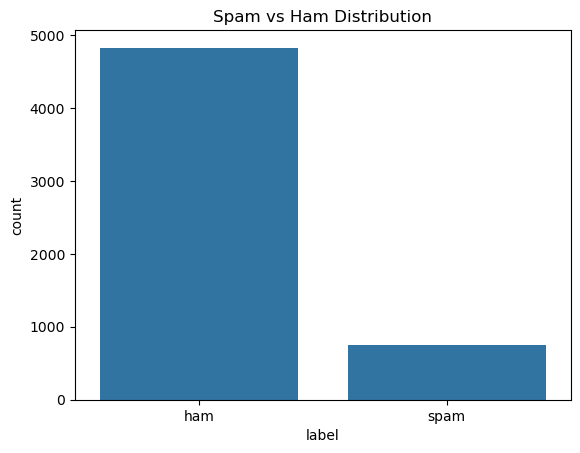

In [14]:
sns.countplot(x='label',data=data)
plt.title('Spam vs Ham Distribution')
plt.show()

In [15]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')  

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\apate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                                                   # lowercase
    text = re.sub(r'\d+', '', text)                                                       # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))                      # remove punctuation
    text = text.strip()                                                                   # remove leading/trailing spaces
    
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    return " ".join(words)


In [17]:
data['message'] = data['message'].apply(clean_text)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])

In [19]:
X = data['message']
y = data['label']

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=8000,stop_words='english')

X_tfidf = tfidf.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_tfidf,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train,y_train)

MultinomialNB()

In [23]:
y_pred = nb_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("naive bayes model accuracy",accuracy_score(y_test,y_pred))

naive bayes model accuracy 0.9659192825112107


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[965   0]
 [ 38 112]]


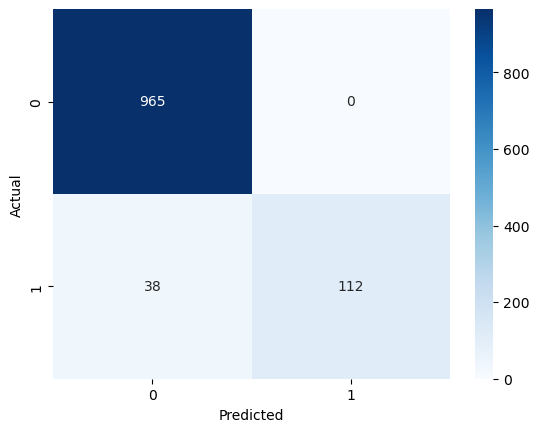

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
message = "Urgent! Your bank account will be blocked.Verify details immediately using this link."
clean_message = clean_text(message)
msg_vector = tfidf.transform([clean_message])
prediction = nb_model.predict(msg_vector)
prediction

array([0])

In [26]:
import pickle
pickle.dump(nb_model,open("backend/model/nb_model.pkl",'wb'))
pickle.dump(tfidf,open("backend/model/tfidf.pkl",'wb'))

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115

